# BEST SDV SYNTHESIZERS SYNTHETIC DATA EVALUATION

## LOAD SYNTH DATA & ORIGINAL FILE

### Unrar synthesizers 

In [1]:
import os
import pandas as pd
import patoolib

pd.set_option("display.max_column",None)


# set path
results_folder = "../results"

# unzip best synth data .rar file
patoolib.extract_archive(os.path.join(results_folder,"best_synth_data.rar"), outdir=results_folder)

patool: Extracting ../results/best_synth_data.rar ...
patool: running /usr/local/bin/rar x -- /usr/local/app/results/best_synth_data.rar
patool:     with cwd='../results'
patool: ... ../results/best_synth_data.rar extracted to `../results'.


'../results'

### Load synthetic data

In [2]:
# set synth data path
file1 = os.path.join(results_folder,"GaussianCopula_best_synth_data.parquet")
file2 = os.path.join(results_folder,"CTGAN_best_synth_data.parquet")
file3 = os.path.join(results_folder,"mostly_ai_synth_data.parquet")

# Load best synth data
copula = pd.read_parquet(file1,engine="pyarrow")
ctgan = pd.read_parquet(file2,engine="pyarrow")
mostly = pd.read_parquet(file3,engine="pyarrow")

### Load original data

In [3]:
# set original data path
orig = os.path.join(results_folder,"preprocessed_file.parquet")

# load original data
diabetes =  pd.read_parquet(orig, engine="pyarrow")

## EVALUATE COLUMNS SHAPE

### Dimensions

In [4]:
print(f"Real dimension: {diabetes.shape}")
print(f"Copula Synth dimension: {copula.shape}")
print(f"CTGAN Synth dimension: {ctgan.shape}")
print(f"Mostly.ai Synth dimension: {mostly.shape}")

Real dimension: (61504, 36)
Copula Synth dimension: (61504, 36)
CTGAN Synth dimension: (61504, 36)
Mostly.ai Synth dimension: (61504, 36)


### Not Null values

In [5]:
# Get information from 3 datasets
real_data_info = pd.DataFrame({
    'Column': diabetes.columns,
    'Real Count':diabetes.notnull().sum()
    })

copula_synth_info = pd.DataFrame({
    'Column': copula.columns,
    'GaussianCopula Count':copula.notnull().sum()
})

ctgan_synth_info = pd.DataFrame({
    'Column': ctgan.columns,
    'CTGAN Count':ctgan.notnull().sum()
})

mostly_synth_info = pd.DataFrame({
    'Column': mostly.columns,
    'MOSTLY.AI Count':mostly.notnull().sum()
})



# Merge the  DataFrames on the 'Column' name
comparison = pd.merge(real_data_info, copula_synth_info, on='Column', how='outer')
comparison = pd.merge(comparison, ctgan_synth_info, on='Column', how='outer')
comparison = pd.merge(comparison, mostly_synth_info, on='Column', how='outer')

# Print comparison table
print("Comparison of Real and Synthetic Data:")
print(comparison)

Comparison of Real and Synthetic Data:
                      Column  Real Count  GaussianCopula Count  CTGAN Count  \
0                       race       61504                 61504        61504   
1                     gender       61504                 61504        61504   
2                        age       61504                 61504        61504   
3          admission_type_id       61504                 61504        61504   
4   discharge_disposition_id       61504                 61504        61504   
5        admission_source_id       61504                 61504        61504   
6           time_in_hospital       61504                 61504        61504   
7                 payer_code       61504                 61504        61504   
8         num_lab_procedures       61504                 61504        61504   
9             num_procedures       61504                 61504        61504   
10           num_medications       61504                 61504        61504   
11         nu

### Check categorical values

#### Same categoricals 

In [6]:
# get categorical column names
orig_cat_cols = diabetes.select_dtypes('object').columns.tolist()
copula_cat_cols = copula.select_dtypes('object').columns.tolist()
ctgan_cat_cols = ctgan.select_dtypes('object').columns.tolist()
# Mostly.ai is string not object
mostly_cat_cols = mostly.select_dtypes('string').columns.tolist()

# evaluate the result
print(f"Same categorical columns: {orig_cat_cols == copula_cat_cols == ctgan_cat_cols == mostly_cat_cols}")

Same categorical columns: True


In [7]:
mostly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61504 entries, 0 to 61503
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   race                      61504 non-null  string
 1   gender                    61504 non-null  string
 2   age                       61504 non-null  string
 3   admission_type_id         61504 non-null  string
 4   discharge_disposition_id  61504 non-null  string
 5   admission_source_id       61504 non-null  string
 6   time_in_hospital          61504 non-null  Int64 
 7   payer_code                61504 non-null  string
 8   num_lab_procedures        61504 non-null  Int64 
 9   num_procedures            61504 non-null  Int64 
 10  num_medications           61504 non-null  Int64 
 11  number_outpatient         61504 non-null  Int64 
 12  number_emergency          61504 non-null  Int64 
 13  number_inpatient          61504 non-null  Int64 
 14  number_diagnoses      

#### Categoricals distribution (SDV synth vs real comparation)

In [8]:
for col in orig_cat_cols:
    # Get information from 3 datasets
    real_data_info = diabetes[col].value_counts(dropna=True).reset_index()
    real_data_info.columns = ['Category', 'Real']

    copula_synth_info = copula[col].value_counts(dropna=True).reset_index()
    copula_synth_info.columns = ['Category', 'GaussianCopula']

    ctgan_synth_info = ctgan[col].value_counts(dropna=True).reset_index()
    ctgan_synth_info.columns = ['Category', 'CTGAN']

    # Merge the DataFrames on the 'Value' name
    comparison = pd.merge(real_data_info, copula_synth_info, on='Category', how='outer')
    comparison = pd.merge(comparison, ctgan_synth_info, on='Category', how='outer')

    # Print comparison table
    print(f"\nComparison of Real and Synthetic Data for column '{col}':")
    print(comparison)


Comparison of Real and Synthetic Data for column 'race':
          Category   Real  GaussianCopula  CTGAN
0        Caucasian  47565           43147  32437
1  AfricanAmerican   9957           13980  25882
2            Other   2562            3385   1836
3         Hispanic   1044             751   1135
4            Asian    376             241    214

Comparison of Real and Synthetic Data for column 'gender':
  Category   Real  GaussianCopula  CTGAN
0   Female  33162           31953  44470
1     Male  28342           29551  17034

Comparison of Real and Synthetic Data for column 'age':
   Category   Real  GaussianCopula  CTGAN
0   [70-80)  15541           14443  21775
1   [60-70)  13587           11987  10498
2   [80-90)  11505            4685  10150
3   [50-60)   9948            8089  11062
4   [40-50)   5536            6076   3342
5   [30-40)   2101            3177    775
6  [90-100)   1999            9825   2178
7   [20-30)   1045            1985   1493
8   [10-20)    228            


Comparison of Real and Synthetic Data for column 'change':
  Category   Real  GaussianCopula  CTGAN
0       Ch  31458           31363  32742
1       No  30046           30141  28762

Comparison of Real and Synthetic Data for column 'diabetesMed':
  Category   Real  GaussianCopula  CTGAN
0      Yes  48944           44647  49930
1       No  12560           16857  11574

Comparison of Real and Synthetic Data for column 'readmitted':
  Category   Real  GaussianCopula  CTGAN
0       NO  33058           24856  34188
1      >30  21716           24347  18410
2      <30   6730           12301   8906

Comparison of Real and Synthetic Data for column 'ICD9_Diag_count':
  Category   Real  GaussianCopula  CTGAN
0        3  60783           55809  59871
1        2    599            5660   1355
2        1    122              35    278


#### Categoricals distribution (Mostly.ai synth vs real comparation)

In [9]:
for col in orig_cat_cols:
    # Get information from 3 datasets
    real_data_info = diabetes[col].value_counts(dropna=True).reset_index()
    real_data_info.columns = ['Category', 'Real']

    mostly_synth_info = mostly[col].value_counts(dropna=True).reset_index()
    mostly_synth_info.columns = ['Category', 'Mostly.ai']

    # Merge the DataFrames on the 'Value' name
    comparison = pd.merge(real_data_info, mostly_synth_info, on='Category', how='outer')

    # Print comparison table
    print(f"\nComparison of Real and Synthetic Data for column '{col}':")
    print(comparison)


Comparison of Real and Synthetic Data for column 'race':
          Category   Real  Mostly.ai
0        Caucasian  47565      48043
1  AfricanAmerican   9957       9612
2            Other   2562       2515
3         Hispanic   1044        991
4            Asian    376        343

Comparison of Real and Synthetic Data for column 'gender':
  Category   Real  Mostly.ai
0   Female  33162      33569
1     Male  28342      27935

Comparison of Real and Synthetic Data for column 'age':
   Category   Real  Mostly.ai
0   [70-80)  15541      15666
1   [60-70)  13587      13664
2   [80-90)  11505      11772
3   [50-60)   9948       9690
4   [40-50)   5536       5230
5   [30-40)   2101       2206
6  [90-100)   1999       1972
7   [20-30)   1045       1083
8   [10-20)    228        213
9    [0-10)     14          8

Comparison of Real and Synthetic Data for column 'admission_type_id':
  Category     Real  Mostly.ai
0        1  34188.0      35028
1        3  12570.0      12220
2        2  11550.0   

### Check numerical values

#### Same numerial columns 

In [10]:
# get numerical column names
orig_cols = diabetes.select_dtypes('int64').columns.tolist()
copula_cols = copula.select_dtypes('int64').columns.tolist()
ctgan_cols = ctgan.select_dtypes('int64').columns.tolist()

# Mostly.ai is Int64 
mostly_cols = mostly.select_dtypes('Int64').columns.tolist()

# evaluate same quantity
print(f"Same numerical columns: {len(orig_cols) == len(copula_cols) == len(ctgan_cols)== len(mostly_cols)}")

Same numerical columns: False


#### Numericals distribution (SDV synth vs real comparation)

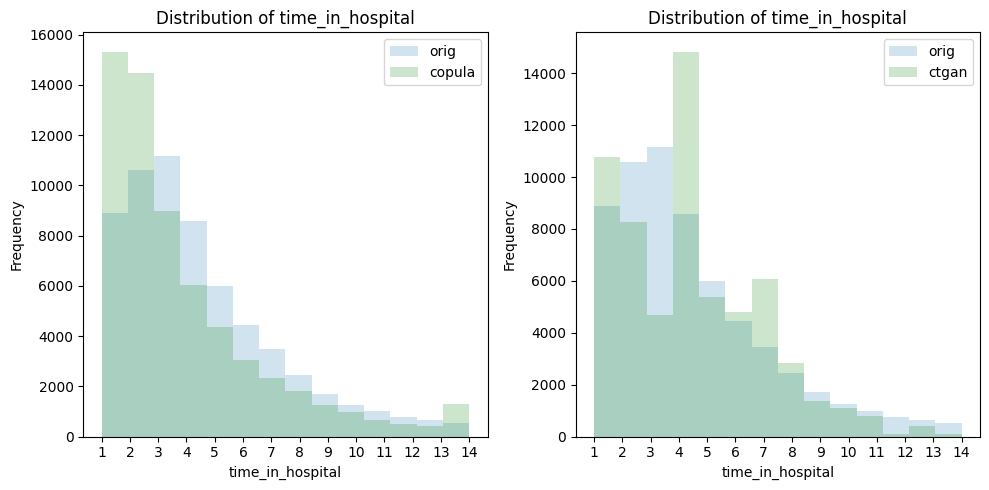

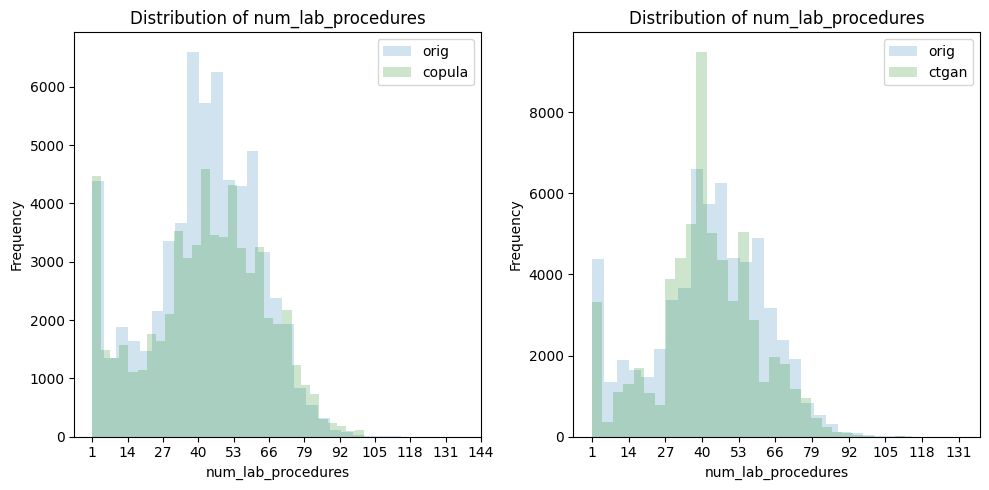

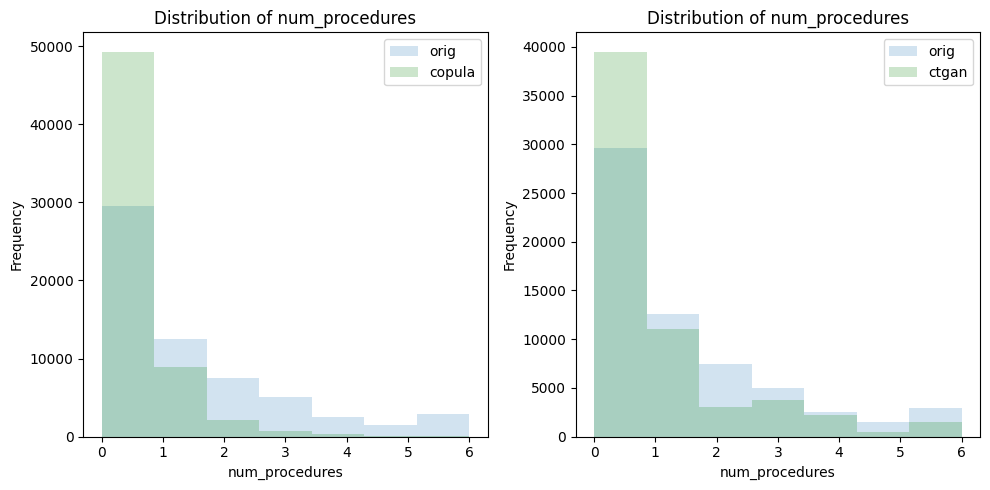

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# FILTER ONLY FIRST 3 COLUMNS
for col in orig_cols[:3]:
    # Plot histogram
    fig, ax = plt.subplots(1,2,figsize=(10, 5))
    
    # Get unique values count for binning (useful for integer columns)
    unique_values = diabetes[col].nunique()
    
    # Set the number of bins based on unique values or a minimum threshold for better visualization
    if unique_values < 30:
        bins = unique_values  # Use number of unique values if less than 30
    else:
        bins = 30  # Default to 30 bins if more than 30 unique values
    
    # Set xticks based on min and max values in the column
    col_min, col_max = diabetes[col].min(), diabetes[col].max()
    
    # Adjust step size for xticks dynamically (if range is small, step=1, else larger step)
    if col_max - col_min < 30:
        step_size = 1
    else:
        step_size = (col_max - col_min) // 10  # Step size as a fraction of the range
    
    
    # orig vs copula
    ax[0].hist(diabetes[col], bins= bins, alpha = 0.2, label = "orig", color="#1f77b4")
    ax[0].hist(copula[col], bins= bins, alpha = 0.2, label = "copula", color = "green")
    ax[0].set_xticks(np.arange(col_min, col_max + step_size, step_size))
    
    # Adjust & show the plot
    ax[0].set_title(f'Distribution of {col}')
    ax[0].set_xlabel(col)
    ax[0].set_ylabel('Frequency')
    ax[0].legend()
    
    # orig vs ctgan
    ax[1].set_xticks(np.arange(col_min, col_max + step_size, step_size))    
    ax[1].hist(diabetes[col], bins= bins, alpha = 0.2, label = "orig", color="#1f77b4")
    ax[1].hist(ctgan[col], bins= bins, alpha = 0.2, label = "ctgan", color = "green")
    
    # Adjust & show the plot
    ax[1].set_title(f'Distribution of {col}')
    ax[1].set_xlabel(col)
    ax[1].set_ylabel('Frequency')
    ax[1].legend()
    
    plt.tight_layout()
    plt.show()

#### Numericals distribution (Mostly.ai synth vs real comparation)

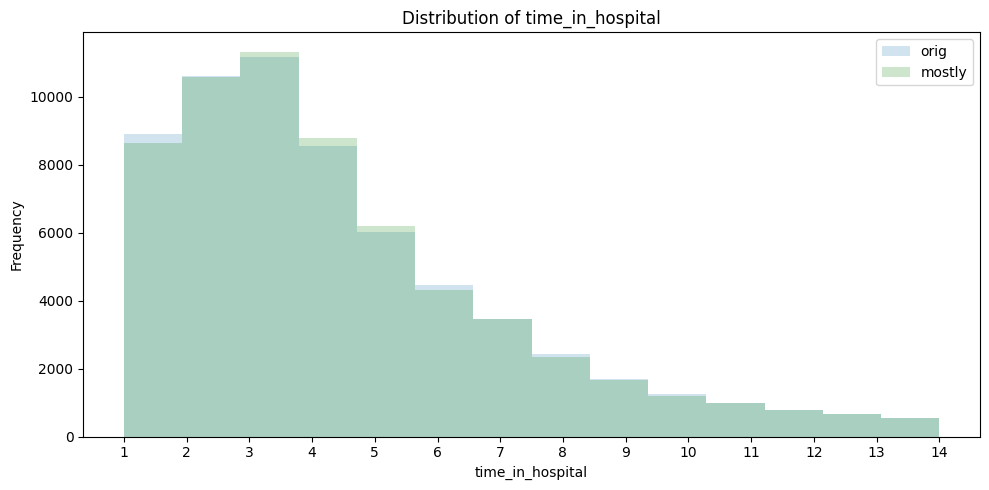

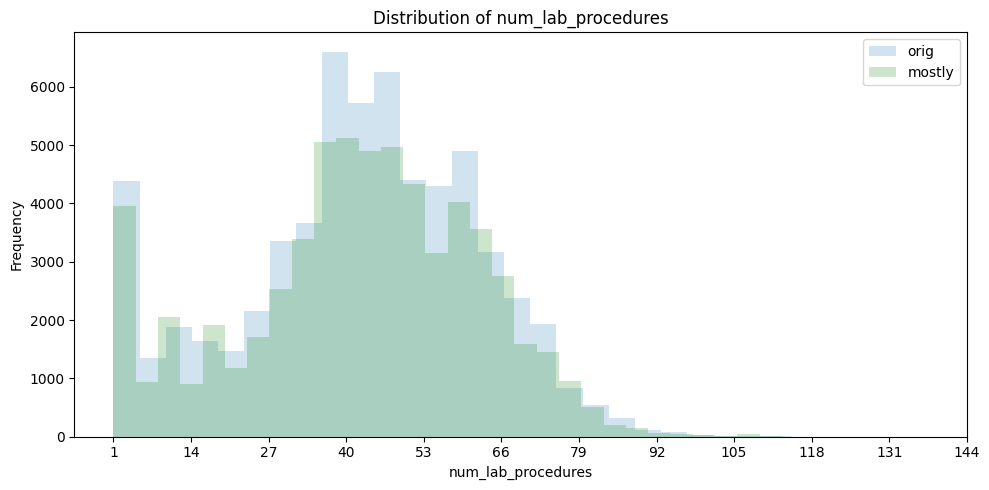

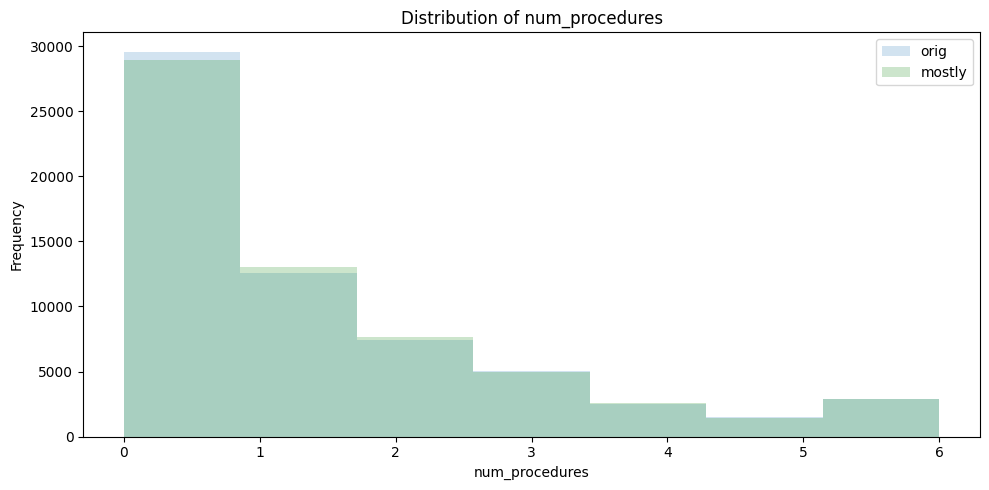

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# FILTER ONLY FIRST 3 COLUMNS
for col in orig_cols[:3]:
    # Plot histogram
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Get unique values count for binning (useful for integer columns)
    unique_values = diabetes[col].nunique()
    
    # Set the number of bins based on unique values or a minimum threshold for better visualization
    if unique_values < 30:
        bins = unique_values  # Use number of unique values if less than 30
    else:
        bins = 30  # Default to 30 bins if more than 30 unique values
    
    # Set xticks based on min and max values in the column
    col_min, col_max = diabetes[col].min(), diabetes[col].max()
    
    # Adjust step size for xticks dynamically (if range is small, step=1, else larger step)
    if col_max - col_min < 30:
        step_size = 1
    else:
        step_size = (col_max - col_min) // 10  # Step size as a fraction of the range
    
    
    # orig vs mostly.ai
    ax.hist(diabetes[col], bins= bins, alpha = 0.2, label = "orig", color="#1f77b4")
    ax.hist(mostly[col], bins= bins, alpha = 0.2, label = "mostly", color = "green")
    ax.set_xticks(np.arange(col_min, col_max + step_size, step_size))
    
    # Adjust & show the plot
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend()
    
  
    plt.tight_layout()
    plt.show()
        

## EVALUATE COLUMNS PAIR

#### Categoricals  (SDV synth vs real comparation)

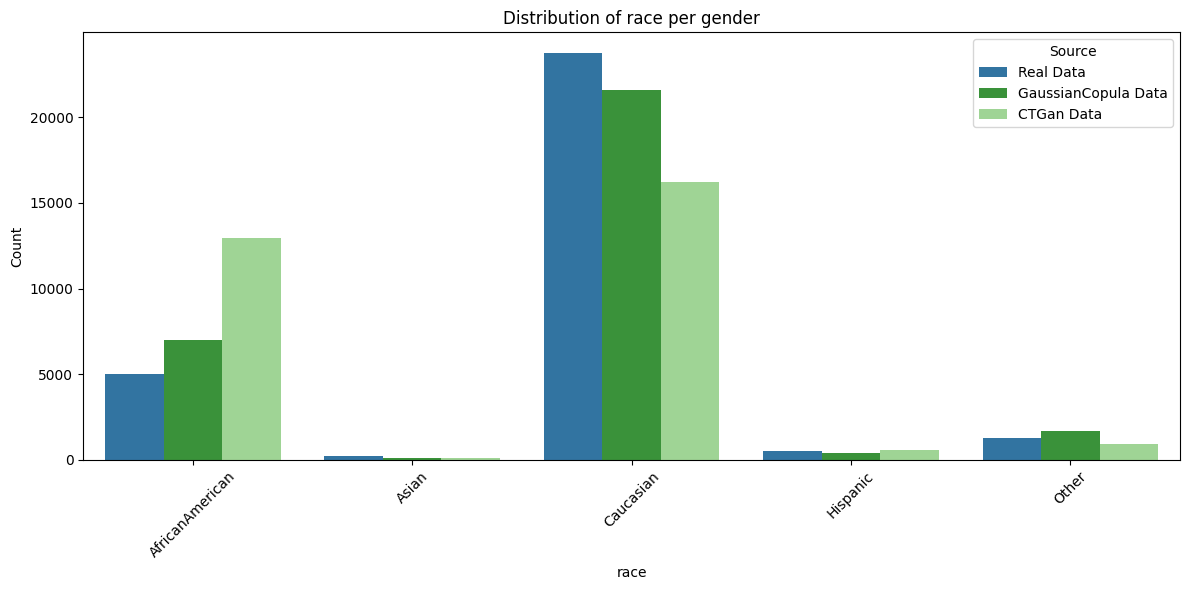

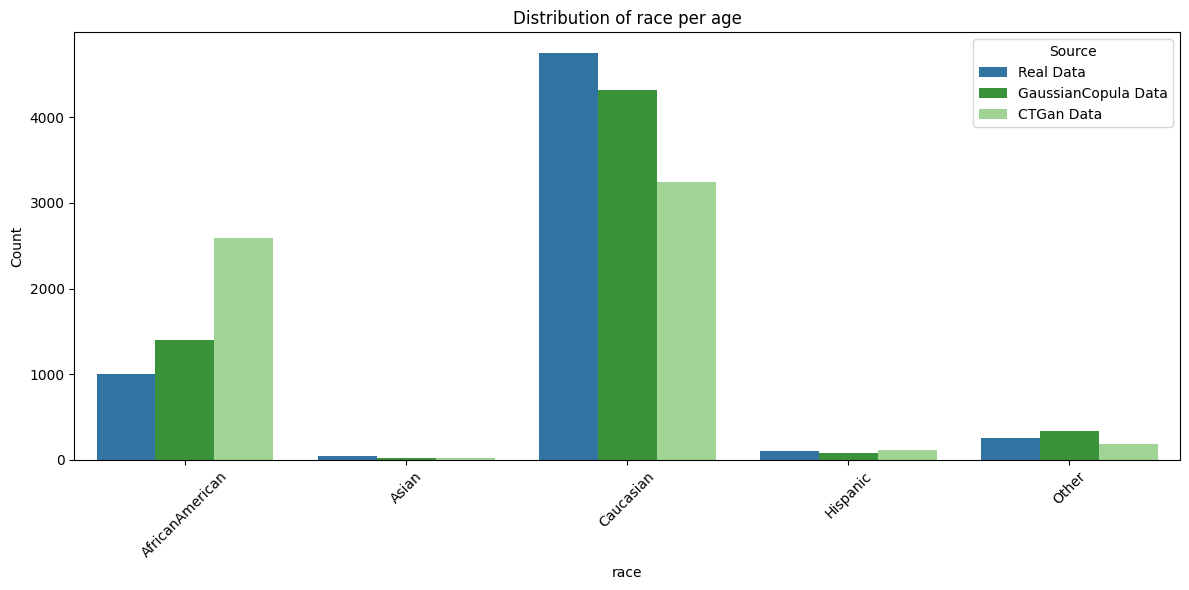

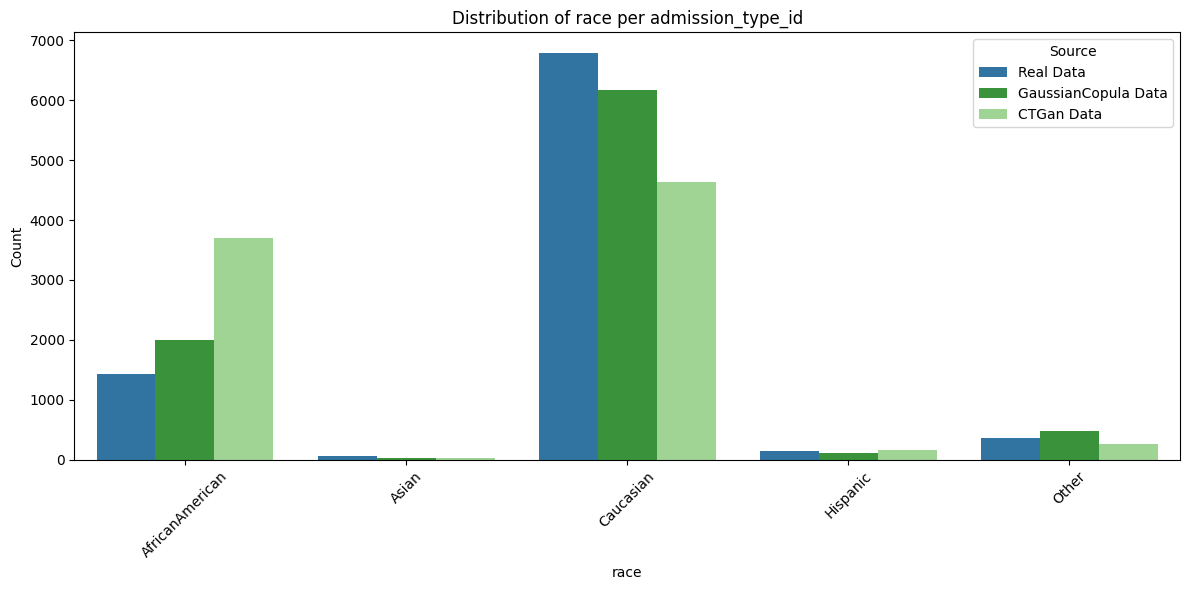

In [13]:
import itertools
import matplotlib.pyplot as plt
import seaborn as sns

# define functions
def plot_combined_df(combined_data, pair_0, pair_1):
    """
    Function that plots bars in comparative mode.

    Parameters:
        combined_data (DataFrame): DataFrame that combines two or more data relationships.
        pair_0 (str): Name of the column to represent on the x-axis.
        pair_1 (str): Name of the column to represent on the y-axis.

    Returns:
        None: This function creates plots in comparative mode.
    """
    # Define a custom palette with blue first and green shades after
    palette = ["#1f77b4", "#2ca02c", "#98df8a"] 

    # Create comparative bar plot by source
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(data=combined_data, x=pair_0, y='Count', hue='Source', palette=palette, errorbar=None, ax=ax)

    # Set the title and labels
    ax.set_title(f'Distribution of {pair_0} per {pair_1}')
    ax.set_xlabel(pair_0)
    ax.set_ylabel('Count')
    plt.xticks(rotation=45)
    plt.legend(title='Source')
    plt.tight_layout()
    plt.show()  


def show_category_pair_relation_sdv(real, copula, ctgan, pair_0, pair_1):
    """
    Function that obtain combined comparative dataframe with real and synthetic data relationships and 
    plots bars in comparative mode.

    Parameters:
        real (Dataframe): Original dataframe.
        copula (DataFrame): Synthetic data created by SDV GaussianCopula sinthesizer.
        ctgan (DataFrame): Synthetic data created by SDV CTGAN sinthesizer.
        pair_0 (str): Name of the column to represent on the x-axis.
        pair_1 (str): Name of the column to represent on the y-axis.

    Returns:
        None: This function obtain combined comparative dataframe and plots in comparative mode.
    """
       
    # Get information from 3 datasets
    real_data_info = real.groupby(pair_0)[pair_1].value_counts(dropna=False).unstack().fillna(0)
    copula_data_info = copula.groupby(pair_0)[pair_1].value_counts(dropna=False).unstack().fillna(0)
    ctgan_data_info = ctgan.groupby(pair_0)[pair_1].value_counts(dropna=False).unstack().fillna(0)

    # Reset index to merge
    real_data_info = real_data_info.reset_index().melt(id_vars=pair_0, var_name=pair_1, value_name='Count')
    copula_data_info = copula_data_info.reset_index().melt(id_vars=pair_0, var_name=pair_1, value_name='Count')
    ctgan_data_info = ctgan_data_info.reset_index().melt(id_vars=pair_0, var_name=pair_1, value_name='Count')

    # Add a source column to distinguish between datasets
    real_data_info['Source'] = 'Real Data'
    copula_data_info['Source'] = 'GaussianCopula Data'
    ctgan_data_info['Source'] = 'CTGan Data'

    # Combine dataframes
    combined_data = pd.concat([real_data_info, copula_data_info, ctgan_data_info], ignore_index=True)

    # plot the result
    if not combined_data.empty:
        plot_combined_df(combined_data, pair_0, pair_1)

def category_pairs (real):
    """
    Function that obtain categorical columns pairs.

    Parameters:
        real (Dataframe): Original dataframe.

    Returns:
        categorical_col_pair: categorical columns pairs.
    """

    # select categorical columns
    categorical_cols = real.select_dtypes('object').columns.tolist()

    # get categorical columns pairs
    categorical_col_pair = list(itertools.combinations(categorical_cols, 2))
    
    return categorical_col_pair

def create_and_show_category_pairs_sdv(real, copula, ctgan):
    """
    Function that obtain categorical columns pairs and visualize in comparative mode

    Parameters:
        real (Dataframe): Original dataframe.
        copula (DataFrame): Synthetic data created by SDV GaussianCopula sinthesizer.
        ctgan (DataFrame): Synthetic data created by SDV CTGAN sinthesizer.

    Returns:
        None: This function obtain categorical column pairs, and show their relation in comparative mode.
    """
    # get categorical columns pairs
    categorical_col_pair = category_pairs(real)

    # DATA FILTERED TO PLOT ONLY FIRST 3
    for pair in categorical_col_pair[:3]:
        
        # create a comparative dataframe and plot comparatively
        show_category_pair_relation_sdv(real=real, copula=copula,
                                        ctgan=ctgan, pair_0=pair[0],
                                        pair_1=pair[1])

        
# Call function
create_and_show_category_pairs_sdv(real = diabetes, copula= copula, ctgan = ctgan)


#### Categoricals  (Mostly.ai synth vs real comparation)

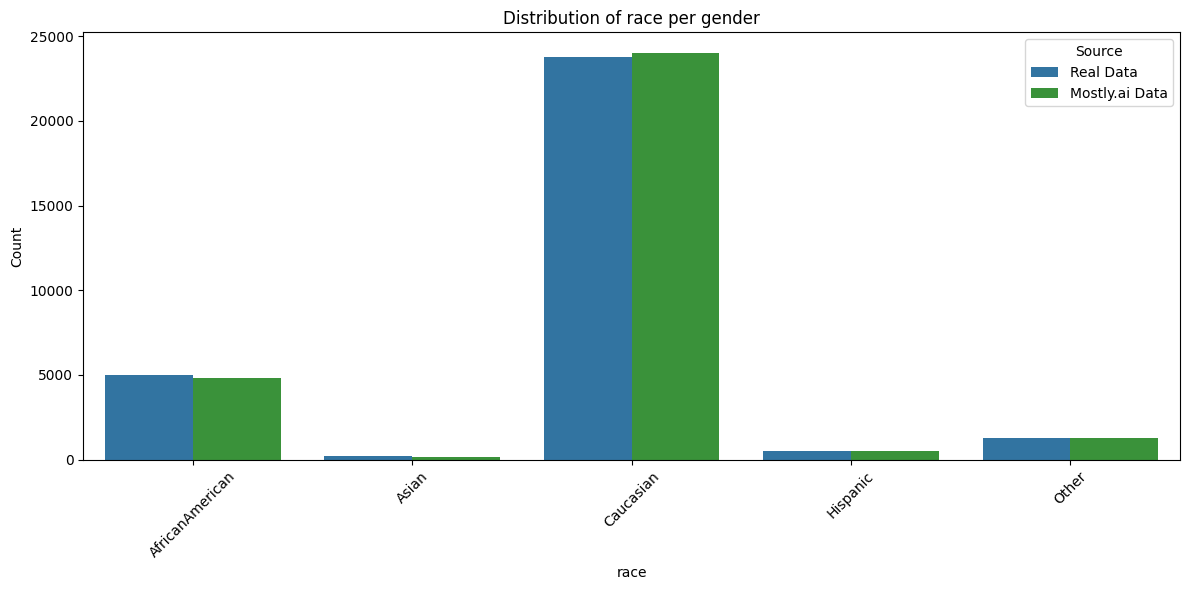

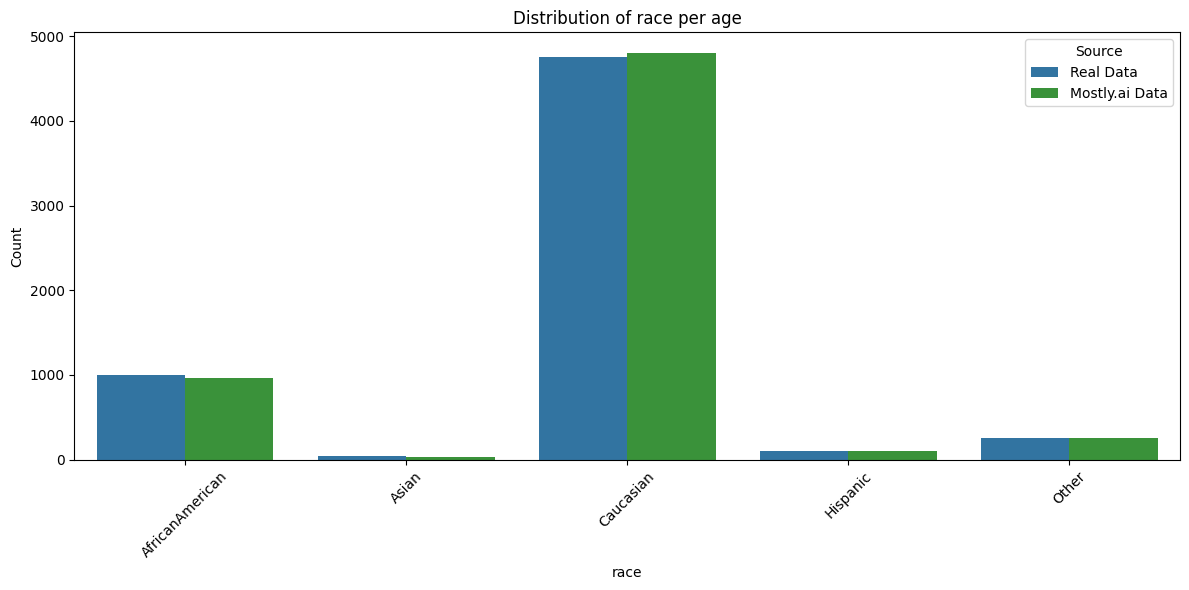

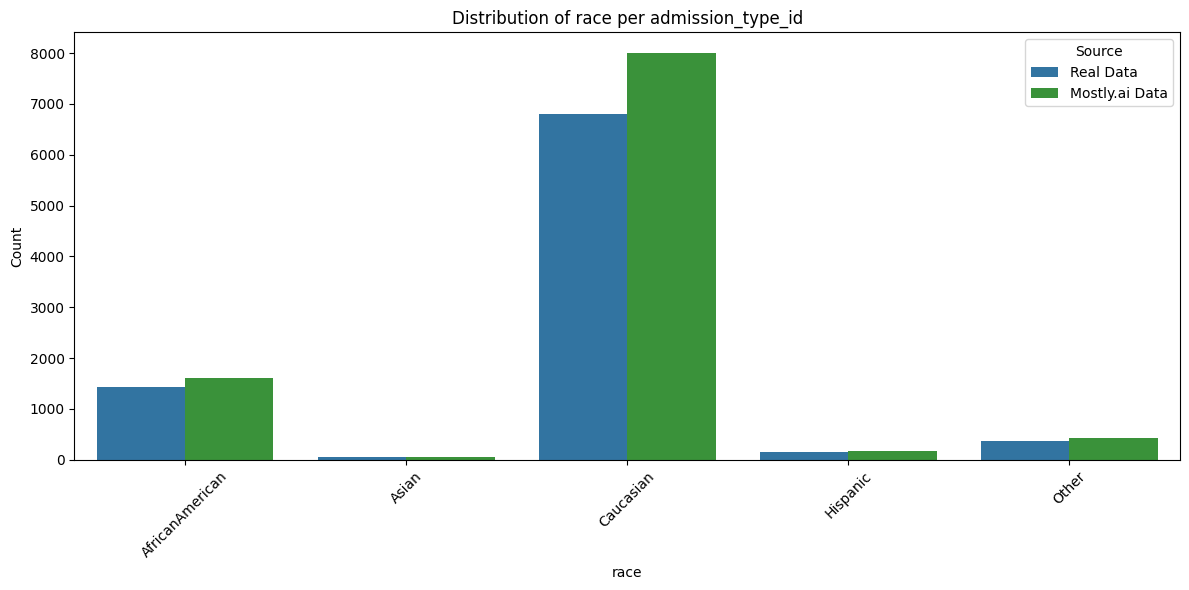

In [14]:
import itertools
import matplotlib.pyplot as plt
import seaborn as sns

# define functions
def show_category_pair_relation(real, mostly, pair_0, pair_1):
    """
    Function that obtain combined comparative dataframe with real and synthetic data relationships and 
    plots bars in comparative mode.

    Parameters:
        real (Dataframe): Original dataframe.
        mostly (DataFrame): Synthetic data created by Mostly.ai.
        pair_0 (str): Name of the column to represent on the x-axis.
        pair_1 (str): Name of the column to represent on the y-axis.

    Returns:
        None: This function obtain combined comparative dataframe and plots in comparative mode.
    """
    # Get information from datasets
    real_data_info = real.groupby(pair_0)[pair_1].value_counts(dropna=False).unstack().fillna(0)
    mostly_data_info = mostly.groupby(pair_0)[pair_1].value_counts(dropna=False).unstack().fillna(0)

    # Prepare for merging
    real_data_info = real_data_info.reset_index().melt(id_vars=pair_0, var_name=pair_1, value_name='Count')
    mostly_data_info = mostly_data_info.reset_index().melt(id_vars=pair_0, var_name=pair_1, value_name='Count')

    # Add a source to distinguish 
    real_data_info['Source'] = 'Real Data'
    mostly_data_info['Source'] = 'Mostly.ai Data'

    # Combine dataframes
    combined_data = pd.concat([real_data_info, mostly_data_info], ignore_index=True)
    
    # plot the result
    if not combined_data.empty:
        plot_combined_df(combined_data, pair_0, pair_1)

def create_and_show_category_pairs(real, mostly):
    """
    Function that obtain categorical columns pairs and visualize in comparative mode

    Parameters:
        real (Dataframe): Original dataframe.
        mostly (DataFrame): Synthetic data created by Mostly.ai.        
    Returns:
        None: This function obtain categorical column pairs, and show their relation in comparative mode.
    """

    # get categorical columns pairs
    categorical_col_pair = category_pairs(real)

    # DATA FILTERED TO PLOT ONLY FIRST 3
    for pair in categorical_col_pair[:3]:
        
        # create a comparative dataframe and plot comparatively
        show_category_pair_relation(real=real, mostly=mostly, 
                                    pair_0=pair[0],pair_1=pair[1])

        

# call to function
create_and_show_category_pairs(real = diabetes, mostly = mostly)
    

#### Numericals (SDV synth vs real comparation)

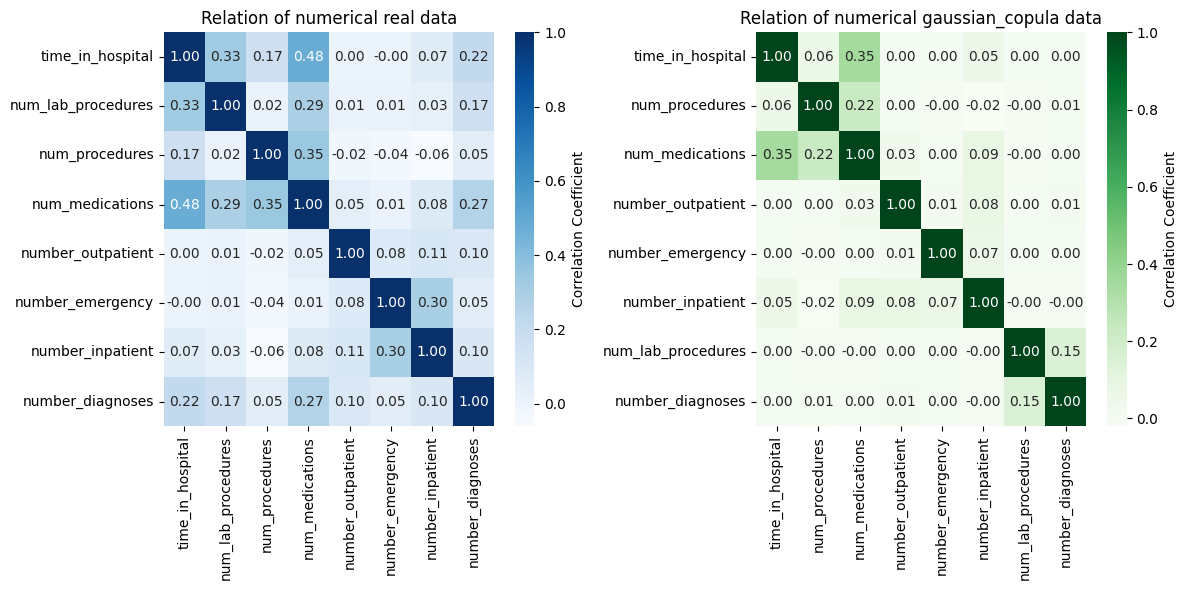

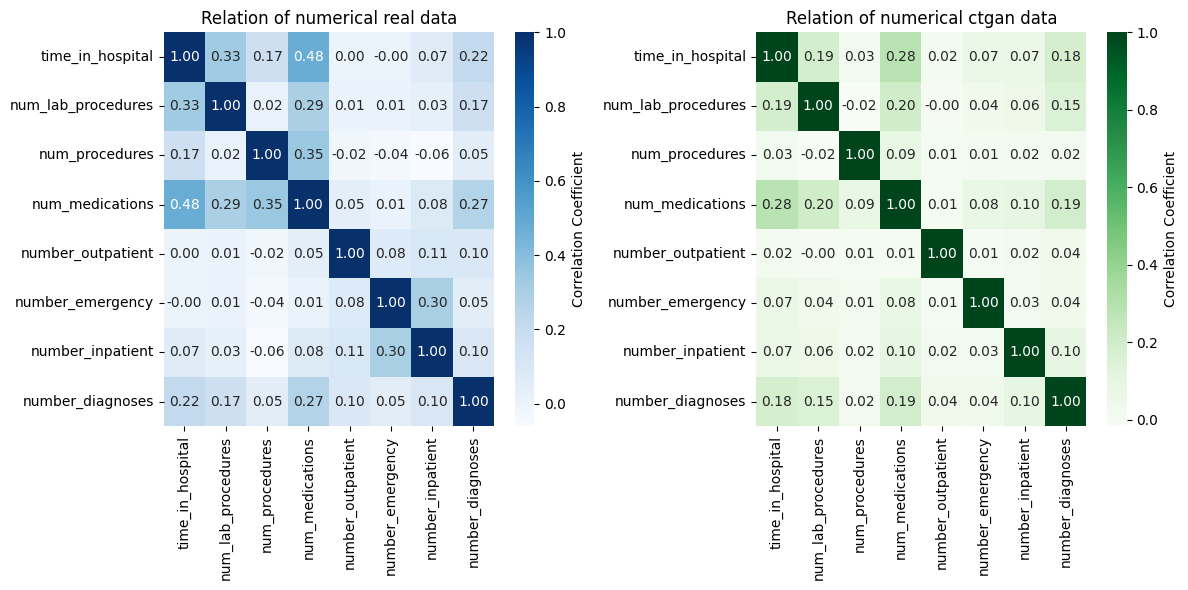

In [15]:
def plot_numerical_correlations(real, synth_data, synth_type):
    """
    Function that plot data correlations between real and synthetic data.

    Parameters:
        real (Dataframe): Original dataframe.
        synth_data (Dataframe): Synthetic dataframe.
        synth_type (str): String that represent the synthesizer used to create synth data: GaussianCopula, CTGAN or Mostly.

    Returns:
        None: This function plots correlations in comparative mode.    """

    # Set the figure size
    fig, ax = plt.subplots(1,2, figsize=(12, 6))
    # real data
    sns.heatmap(real.corr(), ax =ax[0], label = "real", cmap='Blues', 
                cbar_kws={'label': 'Correlation Coefficient'}, 
                annot=True, fmt=".2f")

    # synthetic data
    sns.heatmap(synth_data.corr(), ax =ax[1], label = synth_type, cmap='Greens', 
                cbar_kws={'label': 'Correlation Coefficient'}, 
                annot=True, fmt=".2f")

    # Set the title and labels
    ax[0].set_title('Relation of numerical real data')
    ax[1].set_title(f'Relation of numerical {synth_type} data')
    plt.tight_layout()
    plt.show()  # Show the plot

# plot real vs copula data
plot_numerical_correlations(real = diabetes, 
                            synth_data = copula, 
                            synth_type ="gaussian_copula")

# plot real vs ctgan data
plot_numerical_correlations(real = diabetes, 
                            synth_data = ctgan, 
                            synth_type ="ctgan")

#### Numericals (Mostly.ai synth vs real comparation)

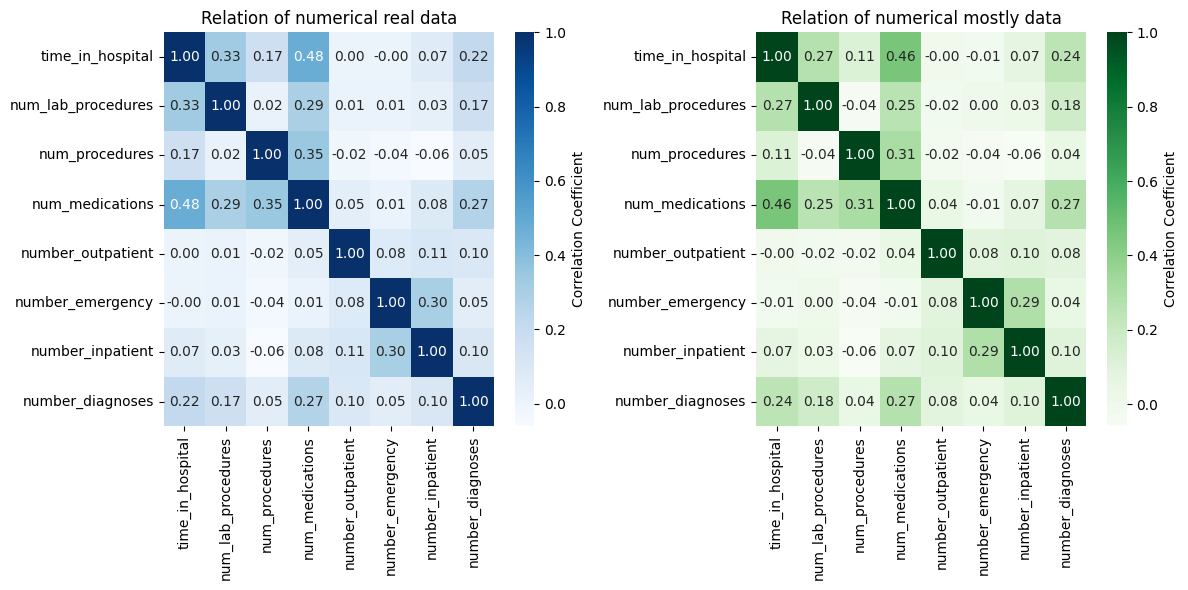

In [16]:
# plot real vs mostly.ai data
plot_numerical_correlations(real = diabetes, 
                            synth_data = mostly, 
                            synth_type ="mostly")